# Project: Transfer Learning


https://pytorch.org/tutorials/beginner/finetuning_torchvision_models_tutorial.html

Report results with k-fold cross-validation.

In [5]:
# Load needed packages
import numpy as np
import seaborn as sns
from sklearn.model_selection import KFold, train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report, cohen_kappa_score, matthews_corrcoef
import torch
import torch.nn as nn
from torch.nn import functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
from torch.utils.data import DataLoader, Dataset, TensorDataset,random_split, ConcatDataset
from torch.utils.data import Subset, WeightedRandomSampler, SubsetRandomSampler
import time
import os
import copy
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from PIL import Image
from tempfile import TemporaryDirectory

import warnings
warnings.filterwarnings('ignore')

cudnn.benchmark = True
plt.ion()   # interactive mode

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# Defining the Device

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


#### Loading and visualizing the data

In [ ]:
pip install torchvision

  Using cached torchvision-0.25.0-cp310-cp310-manylinux_2_28_x86_64.whl (8.1 MB)
  Using cached torch-2.10.0-3-cp310-cp310-manylinux_2_28_x86_64.whl (915.5 MB)


In [ ]:
# Loading the dataset
dataset = torchvision.datasets.ImageFolder(root='')
classes = dataset.classes
n_classes = len(classes)

print("Size of Dataset:", len(dataset))
print("Number of Classes:", len(classes))
print(dataset.classes)

NameError: name 'torchvision' is not defined

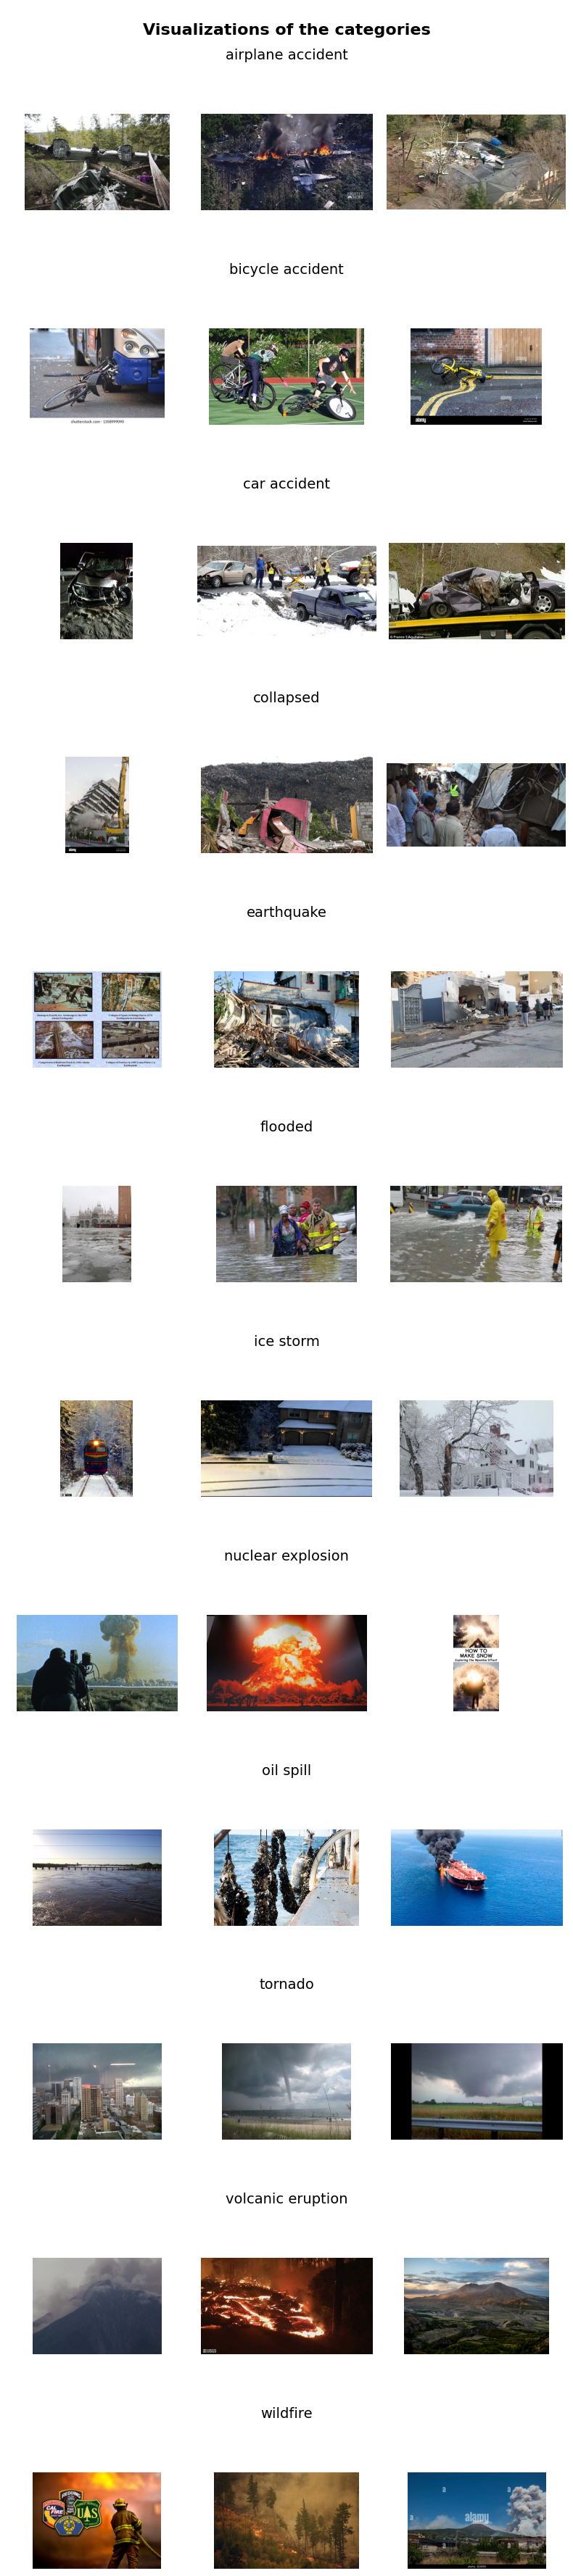

In [ ]:
# Visualizing the dataset
images_per_class = 3

# collecting the images per each class
samples = { cls: [] for cls in range(n_classes)}

for img, label in dataset:
    if len(samples[label]) < images_per_class:
        samples[label].append(img)
    if all(len(samples[c]) == images_per_class for c in samples):
        break
        
# Visualization 
fig, axes = plt.subplots(2 * n_classes, ncols=images_per_class, figsize=(8, 3 * n_classes))
fig.suptitle('Visualizations of the categories', fontsize = 16, weight = "bold")

for cls_idx, cls_name in enumerate(classes):

    label_row = 2 * cls_idx
    image_row = 2 * cls_idx + 1

    # label row 
    for j in range(images_per_class):
        ax = axes[label_row, j]
        ax.axis("off")

        if j == images_per_class // 2:  # center label
            ax.text(0.5, 0.5,cls_name, ha="center", va="center", fontsize=14)

    # image row 
    for j in range(images_per_class):
        ax = axes[image_row, j]
        ax.imshow(samples[cls_idx][j]) 
        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(False)

plt.tight_layout()
plt.show()

#### Checking class distribution and splitting data


Class Distribution:
airplane accident: 872 
bicycle accident: 228 
car accident: 966 
collapsed: 688 
earthquake: 924 
flooded: 957 
ice storm: 615 
nuclear explosion: 231 
oil spill: 293 
tornado: 281 
volcanic eruption: 627 
wildfire: 621 


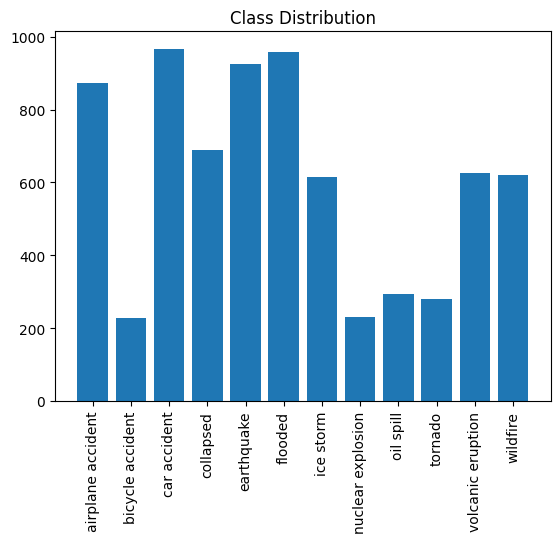

In [ ]:
# Check class distribution
targets = dataset.targets
class_counts = Counter(dataset.targets)
print("\nClass Distribution:")
for cls, count in class_counts.items():
    print(f"{classes[cls]}: {count} ")
    
counts = [class_counts[i] for i in range(len(dataset.classes))]
plt.bar(dataset.classes, counts)
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()

In [ ]:
#  Splitting the dataset (80% for K-Fold CV, 20% for final hold-out test)
indices = np.arange(len(dataset))

# Stratify parameter ensures that the training and testing sets have the same proportion of classes as the original dataset
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=dataset.targets)

print(f"\nTraining set (for K-Fold): {len(train_idx)} samples")
print(f"Hold-out Test set: {len(test_idx)} samples")

train_dataset = Subset(dataset, train_idx)
test_dataset = Subset(dataset, test_idx)


Training set (for K-Fold): 5842 samples
Hold-out Test set: 1461 samples


In [ ]:
# Addressing Class Imbalance with Weighted Sampler

# Get labels from training set
train_labels = [dataset.targets[i] for i in train_idx]
class_counts = Counter(train_labels)
    
# Calculating the class weights (inverse frequency)
class_weights = {cls: len(train_labels) / (count * n_classes) for cls, count in class_counts.items()}
sample_weights = [class_weights[label] for label in train_labels]
sample_weights = torch.DoubleTensor(sample_weights)
    
# Creating a Weighted Random Sampler
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

## Preprocessing

#### Trasforms and augmentations


In [ ]:
# Data transformations
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

In [ ]:
# Applying the transforms to the subsets
class SubsetWithTransform(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# Wrap subsets with transforms
train_dataset  = SubsetWithTransform(train_dataset, transform=train_transform)
test_dataset  = SubsetWithTransform(test_dataset, transform=test_transform)


In [ ]:
# Creating dataloaders
batch_size = 16
num_workers = 4

train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    
    
dataset_sizes = {
        'train': len(train_dataset),
        'test': len(test_dataset)
    }

### Finetuning the Pretrained model

In [ ]:
# Loading a pretrained model and reset final fully connected layer.

model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, n_classes)
model_ft = model_ft.to(device)

# Use weighted loss for imbalance
weight_tensor = torch.FloatTensor([class_weights[i] for i in range(n_classes)]).to(device)
criterion = nn.CrossEntropyLoss(weight=weight_tensor)

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, weight_decay=1e-4)

# Decay LR by a factor of 0.1 every 7 epochs
scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [ ]:
# K-cross validation parameters
torch.manual_seed(42)
num_epochs = 3
batch_size = 32
num_workers= 4
k = 2
splits = StratifiedKFold(n_splits = k, shuffle = True, random_state = 42)
foldperf= {}

# labels corresponding to the train_idx for StratifiedKFold
train_labels_array = np.array([dataset.targets[i] for i in train_idx])

fold_metrics = {
    'fold': [], 'train_acc': [], 'train_loss': [], 
    'val_loss': [], 'val_accuracy': [], 'val_precision': [], 
    'val_recall': [], 'val_f1': [], 'best_epoch': [], 'confusion_matrix': []
}

learning_curves = {
    'train_acc': [], 'train_loss': [], 'val_loss': [], 'val_acc': []
} 

### Training the model

In [ ]:
# K-Fold Loop 
for fold, (train_fold_idx, val_fold_idx) in enumerate(splits.split(train_idx, train_labels_array)):
    print(f"\n{'='*60}")
    print(f"FOLD {fold + 1}/{k}")
   
    # 1. Map indices back to the original dataset indices
    actual_train_indices = [train_idx[i] for i in train_fold_idx]
    actual_val_indices = [train_idx[i] for i in val_fold_idx]
    
    # 2. Create Subsets 
    raw_train_subset = Subset(dataset, actual_train_indices)
    raw_val_subset = Subset(dataset, actual_val_indices)
    
    # 3. Applying Transforms to training sets
    train_dataset_fold = SubsetWithTransform(raw_train_subset, transform=train_transform)
    val_dataset_fold = SubsetWithTransform(raw_val_subset, transform=test_transform)
    
    # 4. Recalculating Class Weights & Sampler for each fold
    # Get labels for the current fold training set
    fold_train_labels = [dataset.targets[i] for i in actual_train_indices]
    fold_class_counts = Counter(fold_train_labels)
    
    # Calculate weights for Sampler
    fold_class_weights_sampler = {cls: len(fold_train_labels) / (count * n_classes) for cls, count in fold_class_counts.items()}
    fold_sample_weights = [fold_class_weights_sampler[label] for label in fold_train_labels]
    fold_sample_weights = torch.DoubleTensor(fold_sample_weights)
    fold_sampler = WeightedRandomSampler(weights=fold_sample_weights, num_samples=len(fold_sample_weights), replacement=True)
    
    # Calculate weights for Loss Function
    fold_loss_weights = torch.FloatTensor([fold_class_weights_sampler.get(i, 1.0) for i in range(n_classes)]).to(device)
    fold_criterion = nn.CrossEntropyLoss(weight=fold_loss_weights)

    # 5. Create DataLoaders
    dataloaders = {
        'train': DataLoader(train_dataset_fold, batch_size=batch_size, sampler=fold_sampler, num_workers=num_workers),
        'val': DataLoader(val_dataset_fold, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    }
    
    dataset_sizes = {
        'train': len(train_dataset_fold),
        'val': len(val_dataset_fold)
    }

    print(f"Training samples: {dataset_sizes['train']}")
    print(f"Validation samples: {dataset_sizes['val']}")
    
    # 6. Initialilizing the Model and tuning
    # Resetting weights ensures each fold is independent
    model_ft = models.resnet18(weights='IMAGENET1K_V1')
    num_ftrs = model_ft.fc.in_features
    model_ft.fc = nn.Linear(num_ftrs, n_classes)
    model_ft = model_ft.to(device)
    
    # Use weighted loss for imbalance
    weight_tensor = torch.FloatTensor([class_weights[i] for i in range(n_classes)]).to(device)
    criterion = nn.CrossEntropyLoss(weight=weight_tensor)
    
    optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, weight_decay=1e-4)
    exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

    # --- Training & Validation Loop for this Fold ---
    best_val_acc = 0.0
    best_val_f1 = 0.0
    best_model_wts = copy.deepcopy(model_ft.state_dict())
    best_epoch = 0
    
    history = {
        'train_acc' : [], 'train_loss': [], 'val_loss': [], 'val_acc': [],
        'val_precision': [], 'val_recall': [], 'val_f1': [],
        'train_precision': [], 'train_recall': [], 'train_f1': [] # Added storage for train metrics
    }
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        epoch_start = time.time()
        
        # Store metrics for this epoch to print later
        epoch_metrics = {'train': {}, 'val': {}}
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model_ft.train()
            else:
                model_ft.eval()
            
            running_loss = 0.0
            running_corrects = 0
            all_preds = []
            all_labels = []
            
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                optimizer_ft.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model_ft(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = fold_criterion(outputs, labels)
                    
                    if phase == 'train':
                        loss.backward()
                        optimizer_ft.step()
                
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
            
            if phase == 'train':
                exp_lr_scheduler.step()
            
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            # Calculate metrics (Precision, Recall, F1) for BOTH train and val
            try:
                epoch_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
                epoch_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
                epoch_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
            except:
                epoch_precision = epoch_recall = epoch_f1 = 0.0
            
            # Store metrics in history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
                history['train_precision'].append(epoch_precision)
                history['train_recall'].append(epoch_recall)
                history['train_f1'].append(epoch_f1)
                
                epoch_metrics['train'] = {
                    'loss': epoch_loss, 'acc': epoch_acc.item(),
                    'precision': epoch_precision, 'recall': epoch_recall, 'f1': epoch_f1
                }
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                history['val_precision'].append(epoch_precision)
                history['val_recall'].append(epoch_recall)
                history['val_f1'].append(epoch_f1)
                
                epoch_metrics['val'] = {
                    'loss': epoch_loss, 'acc': epoch_acc.item(),
                    'precision': epoch_precision, 'recall': epoch_recall, 'f1': epoch_f1
                }
                
                # Track best model based on Validation F1-score
                if epoch_f1 > best_val_f1:
                    best_val_f1 = epoch_f1
                    best_val_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model_ft.state_dict())
                    best_epoch = epoch + 1
        
        # --- Print Metrics for BOTH Train and Val at end of epoch ---
        epoch_time = time.time() - epoch_start
        print(f"Epoch {epoch+1}/{num_epochs} | Time: {epoch_time:.0f}s")
        print(f"  Train | Loss: {epoch_metrics['train']['loss']:.4f} | Acc: {epoch_metrics['train']['acc']:.4f} | "
              f"P: {epoch_metrics['train']['precision']:.4f} | R: {epoch_metrics['train']['recall']:.4f} | F1: {epoch_metrics['train']['f1']:.4f}")
        print(f"  Val   | Loss: {epoch_metrics['val']['loss']:.4f} | Acc: {epoch_metrics['val']['acc']:.4f} | "
              f"P: {epoch_metrics['val']['precision']:.4f} | R: {epoch_metrics['val']['recall']:.4f} | F1: {epoch_metrics['val']['f1']:.4f}")
        print("-" * 60)
    
    total_time = time.time() - start_time
    
    # Load best model for this fold
    model_ft.load_state_dict(best_model_wts)
    
    # Generate Confusion Matrix for this fold
    all_preds_fold = []
    all_labels_fold = []
    model_ft.eval()
    with torch.no_grad():
        for inputs, labels in dataloaders['val']:
            inputs = inputs.to(device)
            outputs = model_ft(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds_fold.extend(preds.cpu().numpy())
            all_labels_fold.extend(labels.cpu().numpy())
    
    cm = confusion_matrix(all_labels_fold, all_preds_fold)
    
    # Store Metrics
    fold_metrics['fold'].append(fold + 1)
    fold_metrics['train_loss'].append(history['train_loss'][-1])
    fold_metrics['train_acc'].append(history['train_acc'][-1])
    fold_metrics['val_loss'].append(history['val_loss'][-1])
    fold_metrics['val_accuracy'].append(best_val_acc.item() if isinstance(best_val_acc, torch.Tensor) else best_val_acc)
    fold_metrics['val_precision'].append(history['val_precision'][best_epoch-1] if best_epoch > 0 else 0)
    fold_metrics['val_recall'].append(history['val_recall'][best_epoch-1] if best_epoch > 0 else 0)
    fold_metrics['val_f1'].append(best_val_f1)
    fold_metrics['best_epoch'].append(best_epoch)
    fold_metrics['confusion_matrix'].append(cm)
    
    learning_curves['train_loss'].append(history['train_loss'])
    learning_curves['train_acc'].append(history['train_acc'])
    learning_curves['val_loss'].append(history['val_loss'])
    learning_curves['val_acc'].append(history['val_acc'])
    
    print(f"\nFold {fold + 1} Complete | Best Epoch: {best_epoch} | Best Val F1: {best_val_f1:.4f} | Time: {total_time:.0f}s")


FOLD 1/15
Training samples: 5452
Validation samples: 390
Epoch 1/30 | Time: 34s
  Train | Loss: 2.0390 | Acc: 0.2065 | P: 0.2288 | R: 0.2065 | F1: 0.1289
  Val   | Loss: 2.1298 | Acc: 0.1231 | P: 0.2744 | R: 0.1231 | F1: 0.0694
------------------------------------------------------------
Epoch 2/30 | Time: 30s
  Train | Loss: 1.4456 | Acc: 0.3832 | P: 0.4909 | R: 0.3832 | F1: 0.3027
  Val   | Loss: 1.6658 | Acc: 0.2590 | P: 0.4965 | R: 0.2590 | F1: 0.2358
------------------------------------------------------------
Epoch 3/30 | Time: 30s
  Train | Loss: 1.1365 | Acc: 0.5121 | P: 0.6029 | R: 0.5121 | F1: 0.4632
  Val   | Loss: 1.3915 | Acc: 0.4077 | P: 0.6643 | R: 0.4077 | F1: 0.4050
------------------------------------------------------------
Epoch 4/30 | Time: 30s
  Train | Loss: 0.9427 | Acc: 0.6005 | P: 0.6682 | R: 0.6005 | F1: 0.5733
  Val   | Loss: 1.2079 | Acc: 0.5000 | P: 0.7140 | R: 0.5000 | F1: 0.5049
------------------------------------------------------------
Epoch 5/30 | T

### Model evaluation 

In [ ]:
#  Retraining on full training set 

best_final_f1 = 0.0
best_final_wts = copy.deepcopy(model_ft.state_dict())

print(f"Training final model for {num_epochs} epochs on {len(train_dataset)} samples...")

for epoch in range(num_epochs):
    model_ft.train()
    running_loss = 0.0
    running_corrects = 0
    all_preds = []
    all_labels = []
    
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer_ft.zero_grad()
        
        with torch.set_grad_enabled(True):
            outputs = model_ft(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer_ft.step()
        
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    scheduler.step()
    
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    if epoch_f1 > best_final_f1:
        best_final_f1 = epoch_f1
        best_final_wts = copy.deepcopy(model_ft.state_dict())
    
    if (epoch + 1) % 2 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} | F1: {epoch_f1:.4f}")

# Load best weights
model_ft.load_state_dict(best_final_wts)
print(f"✓ Final model trained. Best Training F1: {best_final_f1:.4f}")


Training final model for 30 epochs on 5842 samples...
Epoch 1/30 | Loss: 0.6760 | Acc: 0.7314 | F1: 0.7231
Epoch 2/30 | Loss: 0.6851 | Acc: 0.7244 | F1: 0.7156
Epoch 4/30 | Loss: 0.6900 | Acc: 0.7316 | F1: 0.7220
Epoch 6/30 | Loss: 0.6637 | Acc: 0.7398 | F1: 0.7318
Epoch 8/30 | Loss: 0.6983 | Acc: 0.7230 | F1: 0.7153
Epoch 10/30 | Loss: 0.6972 | Acc: 0.7224 | F1: 0.7127
Epoch 12/30 | Loss: 0.6896 | Acc: 0.7232 | F1: 0.7144
Epoch 14/30 | Loss: 0.6906 | Acc: 0.7289 | F1: 0.7218
Epoch 16/30 | Loss: 0.7083 | Acc: 0.7295 | F1: 0.7226
Epoch 18/30 | Loss: 0.7111 | Acc: 0.7237 | F1: 0.7160
Epoch 20/30 | Loss: 0.6991 | Acc: 0.7335 | F1: 0.7267
Epoch 22/30 | Loss: 0.6760 | Acc: 0.7400 | F1: 0.7319
Epoch 24/30 | Loss: 0.6851 | Acc: 0.7266 | F1: 0.7175
Epoch 26/30 | Loss: 0.6938 | Acc: 0.7222 | F1: 0.7122
Epoch 28/30 | Loss: 0.6784 | Acc: 0.7342 | F1: 0.7265
Epoch 30/30 | Loss: 0.6963 | Acc: 0.7222 | F1: 0.7139
✓ Final model trained. Best Training F1: 0.7352


In [ ]:
# Evaluating on Hold-out Test Set 
model_ft.eval()
test_preds = []
test_labels = []
test_probs = []  # For ROC analysis if needed

test_loaders = DataLoader(
    test_dataset,  # Already transformed earlier
    batch_size=batch_size, 
    shuffle=False,  # Important: keep order for confusion matrix
    num_workers=num_workers
)

with torch.no_grad():
    for inputs, labels in test_loaders:
        inputs = inputs.to(device)
        outputs = model_ft(inputs)
        _, preds = torch.max(outputs, 1)
        probs = torch.softmax(outputs, dim=1)
        
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())

# Calculate Test Metrics
test_accuracy = accuracy_score(test_labels, test_preds)
test_precision = precision_score(test_labels, test_preds, average='weighted', zero_division=0)
test_recall = recall_score(test_labels, test_preds, average='weighted', zero_division=0)
test_f1 = f1_score(test_labels, test_preds, average='weighted', zero_division=0)
test_kappa = cohen_kappa_score(test_labels, test_preds)
test_mcc = matthews_corrcoef(test_labels, test_preds)

print(f" HOLD-OUT TEST SET RESULTS")
print(f"{'-'*40}")
print(f"Samples: {len(test_labels)}")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"Cohen's κ: {test_kappa:.4f}")
print(f"MCC:       {test_mcc:.4f}")
print(f"{'-'*40}")
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=classes, zero_division=0))

# Store for visualizations
all_test_labels = test_labels
all_test_preds = test_preds


 HOLD-OUT TEST SET RESULTS
----------------------------------------
Samples: 1461
Accuracy:  0.6913
Precision: 0.7476
Recall:    0.6913
F1-Score:  0.6927
Cohen's κ: 0.6605
MCC:       0.6660
----------------------------------------

Classification Report:
                   precision    recall  f1-score   support

airplane accident       0.80      0.44      0.57       174
 bicycle accident       0.36      0.89      0.51        46
     car accident       0.82      0.79      0.80       193
        collapsed       0.45      0.75      0.56       138
       earthquake       0.76      0.36      0.49       185
          flooded       0.83      0.78      0.80       192
        ice storm       0.81      0.70      0.75       123
nuclear explosion       0.56      0.87      0.68        46
        oil spill       0.48      0.80      0.60        59
          tornado       0.71      0.91      0.80        56
volcanic eruption       0.90      0.75      0.82       125
         wildfire       0.90      0.

### Results

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

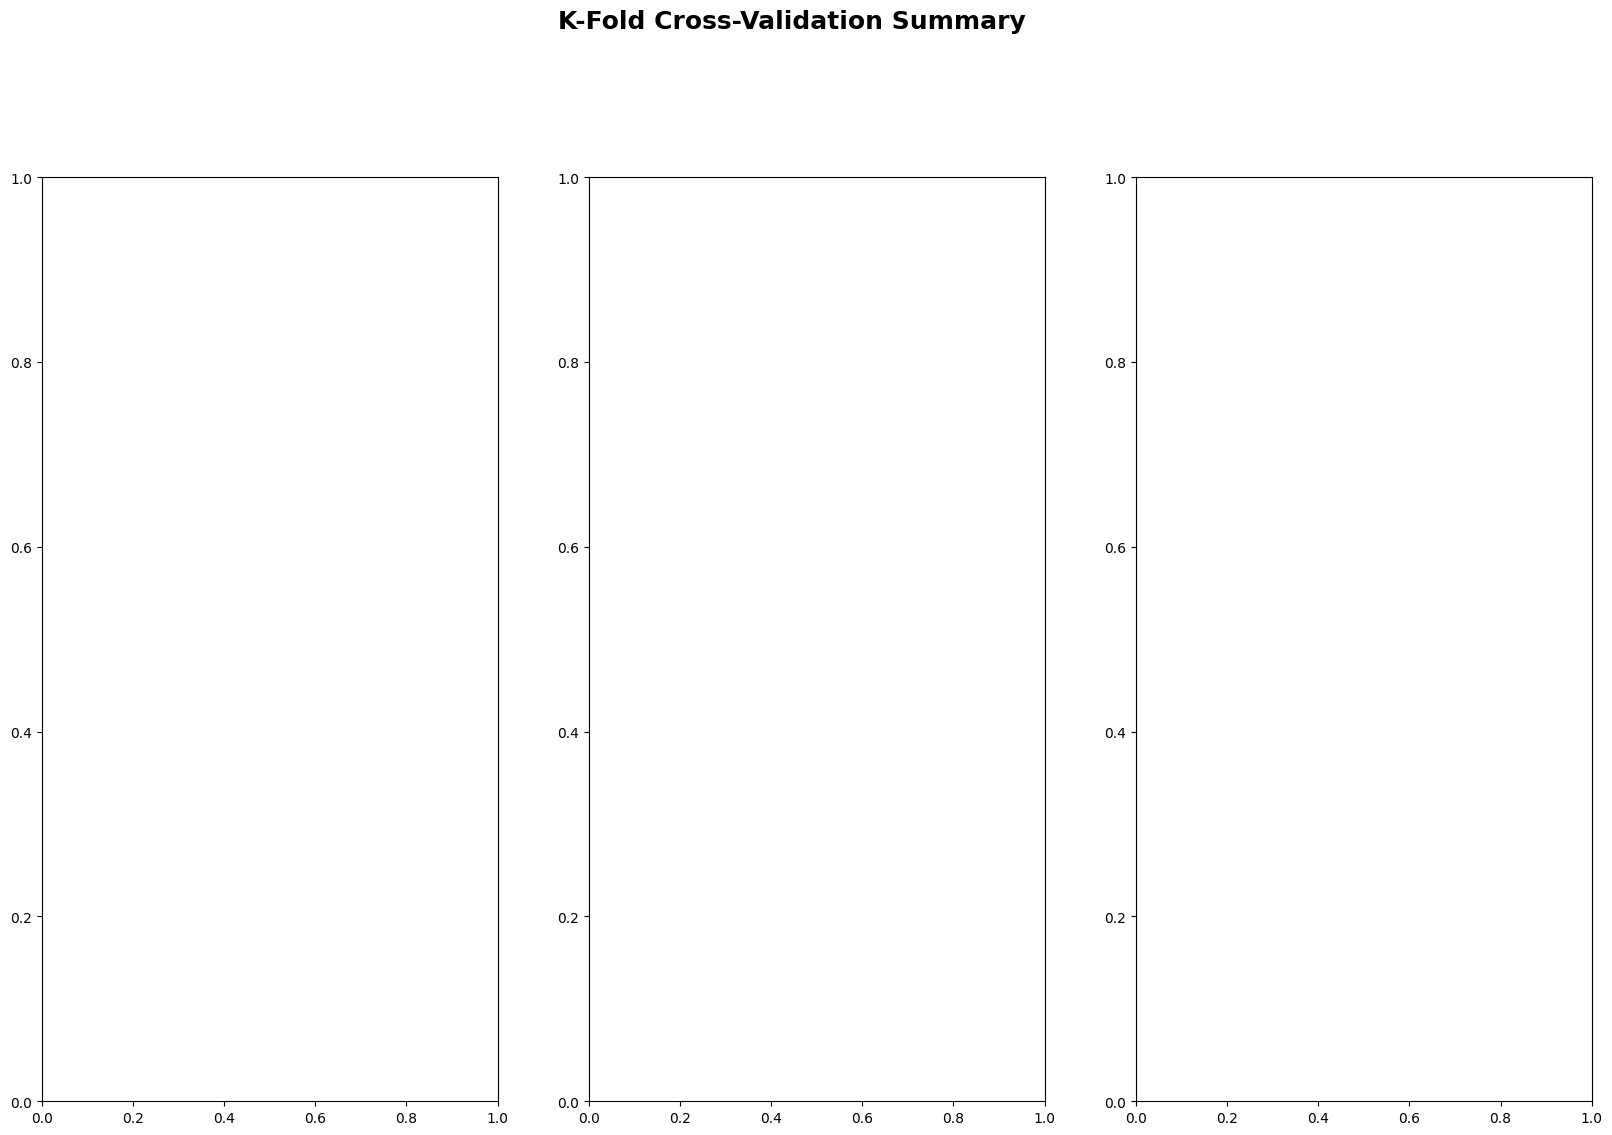

In [ ]:
# --- Figure 1: K-Fold Summary Dashboard (2x3 Grid) ---
fig, axes = plt.subplots(1, 3, figsize=(20, 12))
fig.suptitle('K-Fold Cross-Validation Summary', fontsize=18, fontweight='bold', y=1.02)

# Plot 1: Learning Curves (Average ± Std)
ax = axes[0]
avg_train_loss = np.mean(learning_curves['train_loss'], axis=0)
avg_val_loss = np.mean(learning_curves['val_loss'], axis=0)
std_train_loss = np.std(learning_curves['train_loss'], axis=0)
std_val_loss = np.std(learning_curves['val_loss'], axis=0)

epochs_range = range(1, num_epochs + 1)
ax.plot(epochs_range, avg_train_loss, 'b-', label='Train Loss', linewidth=2)
ax.fill_between(epochs_range, avg_train_loss - std_train_loss, avg_train_loss + std_train_loss, alpha=0.2, color='b')
ax.plot(epochs_range, avg_val_loss, 'r-', label='Val Loss', linewidth=2)
ax.fill_between(epochs_range, avg_val_loss - std_val_loss, avg_val_loss + std_val_loss, alpha=0.2, color='r')
ax.set_xlabel('Epoch', fontsize=10)
ax.set_ylabel('Loss', fontsize=10)
ax.set_title('Average Learning Curves (±1 Std)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 2: Train vs Val Accuracy Comparison 
ax = axes[1]
train_acc_final = [acc[-1] for acc in learning_curves['train_acc']]
val_acc_final = fold_metrics['val_accuracy']
x = np.arange(len(fold_metrics['fold']))
ax.plot(x + 1, train_acc_final, 'bo-', label='Train Acc', markersize=8, linewidth=2)
ax.plot(x + 1, val_acc_final, 'rs-', label='Val Acc', markersize=8, linewidth=2)
ax.fill_between(x + 1, train_acc_final, val_acc_final, alpha=0.2, color='gray', 
                label='Generalization Gap')
ax.set_xlabel('Fold', fontsize=10)
ax.set_ylabel('Accuracy', fontsize=10)
ax.set_title('Train vs Validation Accuracy', fontsize=11, fontweight='bold')
ax.set_xticks(x + 1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Plot 3: F1-Score per Fold (COMPLETED GRID)
ax = axes[2]
ax.plot(fold_metrics['fold'], fold_metrics['val_f1'], 'mo-', markersize=10, 
        linewidth=2, label='F1-Score', markerfacecolor='purple')
mean_f1 = np.mean(fold_metrics['val_f1'])
ax.axhline(y=mean_f1, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_f1:.4f}')
ax.set_xlabel('Fold', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_title('F1-Score per Fold', fontsize=11, fontweight='bold')
ax.set_xticks(fold_metrics['fold'])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')



# --- Figure 2: Test Set Confusion Matrix (Enhanced) ---
plt.figure(figsize=(12, 10))
test_cm = confusion_matrix(all_test_labels, all_test_preds)
sns.heatmap(test_cm, annot=True, fmt='d', cmap='PuRd', 
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Count'}, linewidths=0.5)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title(f'Hold-out Test Set Confusion Matrix (n={len(test_labels)})\nAccuracy: {test_accuracy:.4f}', 
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('test_confusion_matrix.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✓ Test confusion matrix saved as 'test_confusion_matrix.png'")
plt.show()


# --- Figure 3: Class-wise Performance on Test Set (NEW) ---
# Per-class precision, recall, F1
from sklearn.metrics import precision_recall_fscore_support

per_class_metrics = precision_recall_fscore_support(
    all_test_labels, all_test_preds, average=None, zero_division=0
)

plt.figure(figsize=(14, 6))
x = np.arange(len(classes))
width = 0.25

plt.bar(x - width, per_class_metrics[0], width, label='Precision', color='#4E79A7', alpha=0.8)
plt.bar(x, per_class_metrics[1], width, label='Recall', color='#F28E2B', alpha=0.8)
plt.bar(x + width, per_class_metrics[2], width, label='F1-Score', color='#76B7B2', alpha=0.8)

plt.xlabel('Class', fontsize=11, fontweight='bold')
plt.ylabel('Score', fontsize=11, fontweight='bold')
plt.title('Per-Class Performance on Hold-out Test Set', fontsize=14, fontweight='bold', pad=20)
plt.xticks(x, classes, rotation=45, ha='right')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('test_per_class_metrics.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✓ Per-class metrics saved as 'test_per_class_metrics.png'")
plt.show()
